___

# Qiskit IBM Runtime

Agora vamos estudar um pouco sobre o Qiskit Runtime client, que é uma biblioteca que permite utilizar computadores quanticos reais assim como simuladores. Estudaremos as primitivas no pacote `qiskit_ibm_runtime`, Estimator e o Sampler.

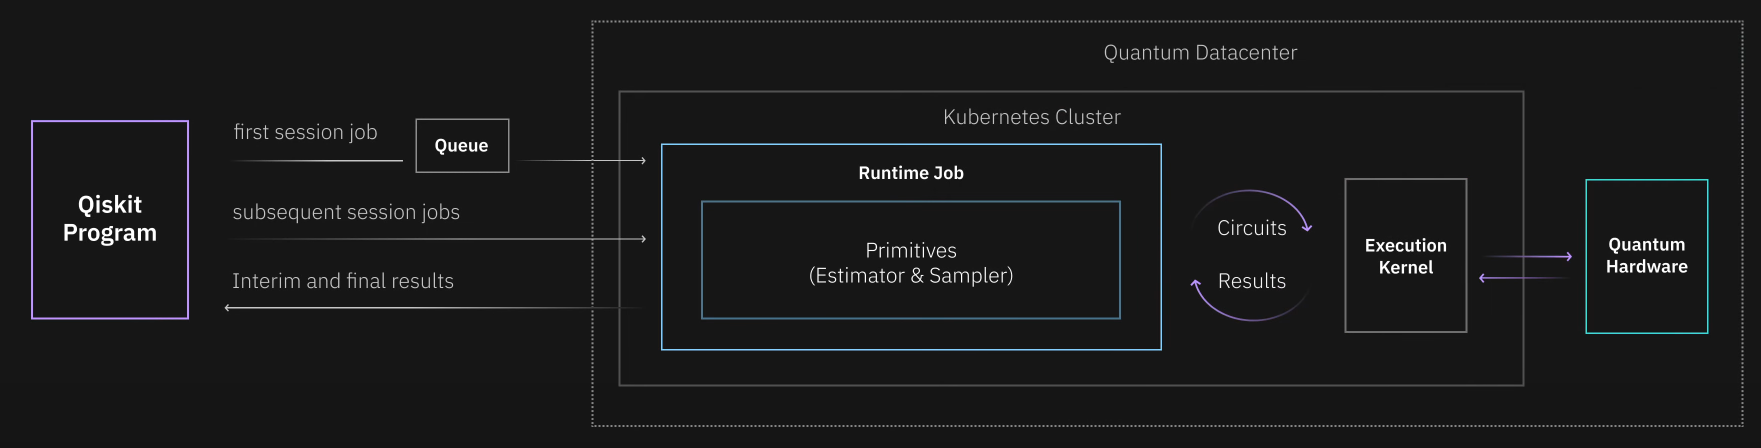


Primeiro, vamos entender o conceito de *session*. Quando criamos um job (`RuntimeJobV2`) por meio do método `.run()` em uma primitiva, o enviamos para um *scheduler* que é responsável por ordenar a fila de pedidos de tarefas quanticas, e se esse jobs forem submetidos na mesma *session* eles serão priorizados pelo *scheduler*, assim perimitindo uma interface efficiente para rodar Quantum hybrid Computatios, que são computações que dependem tanto de um QPU quanto de computação tradicional (`VQE`)

Assim como com o `qiskit.primitives`, aqui temos as versões V1 e V2 das primitivas, onde a versão V1 está deprecated, portanto apenas vamos cobrir o V2. 

___

## SamplerV2

`SamplerV2(mode=None, options=None)`

‎ 

- **mode** (Optional[Union[BackendV2, Session, Batch]]) :

    The execution mode used to make the primitive query. It can be:

    A Backend if you are using job mode.
    A Session if you are using session execution mode.
    A Batch if you are using batch execution mode.

‎

- **options** (Optional[Union[Dict, SamplerOptions]]) :

    Sampler options, see SamplerOptions for detailed description.

In [4]:
import time
import pprint
import warnings
import numpy as np
from tqdm.notebook import tqdm
from math import pi

from qiskit import QuantumCircuit, schedule
from qiskit.circuit import *
from qiskit.primitives import BackendEstimator
from qiskit.primitives import StatevectorEstimator, StatevectorSampler
from qiskit.quantum_info import SparsePauliOp
from qiskit.providers.basic_provider import BasicSimulator
from qiskit import transpile
from qiskit_aer import *
from qiskit_aer.primitives import Estimator as Aer_EstimatorV1, EstimatorV2 as Aer_EstimatorV2
from qiskit_ibm_runtime import SamplerV2 as runtime_SamplerV2, EstimatorV2 as runtime_EstimatorV2, QiskitRuntimeService

from qiskit.visualization import plot_histogram, plot_distribution
import matplotlib.pyplot as plt

plt.style.use('dark_background')

plt.rcParams.update({
    'figure.facecolor':   '#282c34',  
    'axes.facecolor':     '#1e1e1e',    
    'grid.color':         '#444444',

    'figure.figsize': (10, 6),
    'figure.dpi': 150
})    

In [24]:
QiskitRuntimeService().backends(simulator = True)

[]

In [7]:
QiskitRuntimeService().backends()

[<IBMBackend('ibm_brisbane')>, <IBMBackend('ibm_torino')>]

In [9]:
QiskitRuntimeService().least_busy()

<IBMBackend('ibm_brisbane')>

In [10]:
backend_aer = AerSimulator()
backend_bri = QiskitRuntimeService().get_backend('ibm_brisbane')

In [12]:
sampler_aer = runtime_SamplerV2(backend=backend_aer)
sampler_bri = runtime_SamplerV2(backend=backend_bri)

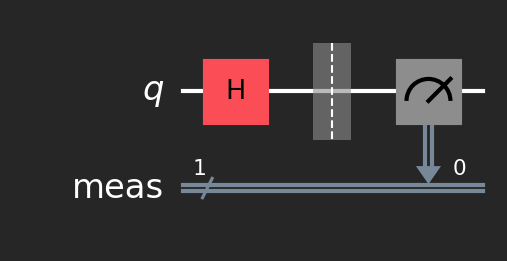

In [13]:
qc1 = QuantumCircuit(1)
qc1.h(0)
qc1.measure_all()
qc1.draw()

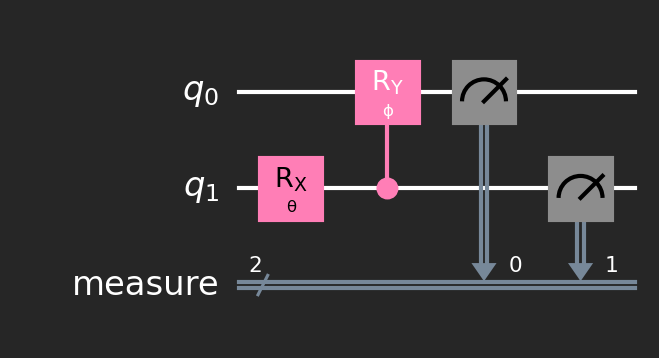

In [16]:
θ = Parameter('θ')
ϕ = Parameter('ϕ')

qr = QuantumRegister(2, name='q')
cr = ClassicalRegister(2, name='measure')

qc2 = QuantumCircuit(qr, cr)
qc2.rx(θ,1)
qc2.cry(ϕ,1,0)
qc2.measure(qr,cr)
qc2.draw()

In [19]:
print(qc2.parameters)

angles = [[pi/4, pi/2], [pi/3,pi], [pi/2,pi]]

ParameterView([Parameter(θ), Parameter(ϕ)])


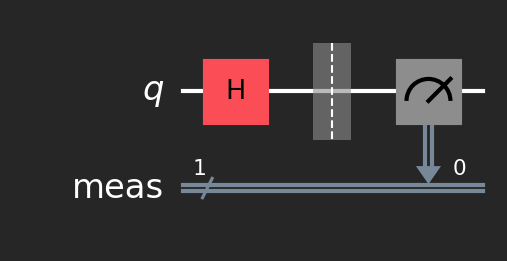

In [20]:
qc1_aer = transpile(qc1, backend=backend_aer)
qc1_aer.draw()

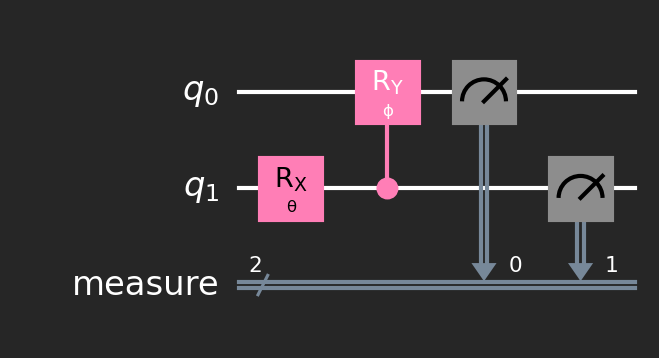

In [21]:

qc2_aer = transpile(qc2, backend=backend_aer)
qc2_aer.draw()

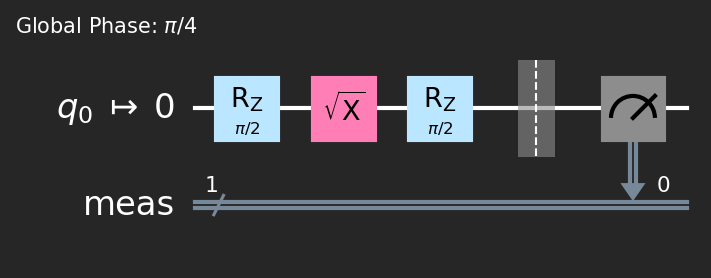

In [22]:

qc1_bri = transpile(qc1, backend=backend_bri)
qc1_bri.draw(idle_wires=False)

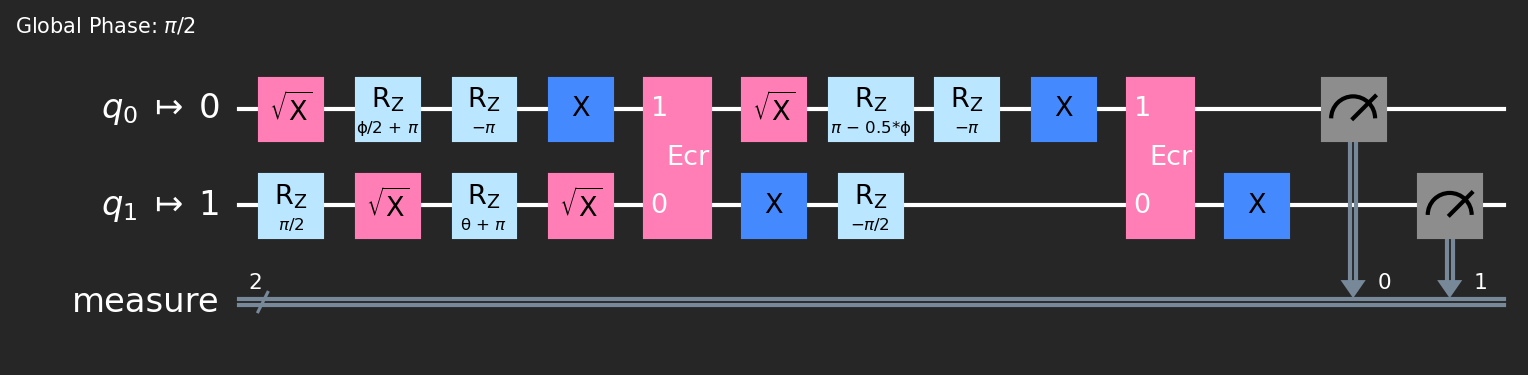

In [23]:
qc2_bri = transpile(qc2, backend=backend_bri)
qc2_bri.draw(idle_wires=False)

In [ ]:
job_aer = sampler_aer.run([(qc1_aer,None,100),(qc2_aer,angles,1000)])
#job_bri = sampler_bri.run([(qc1_bri,None,100),(qc2_bri,angles,1000)])

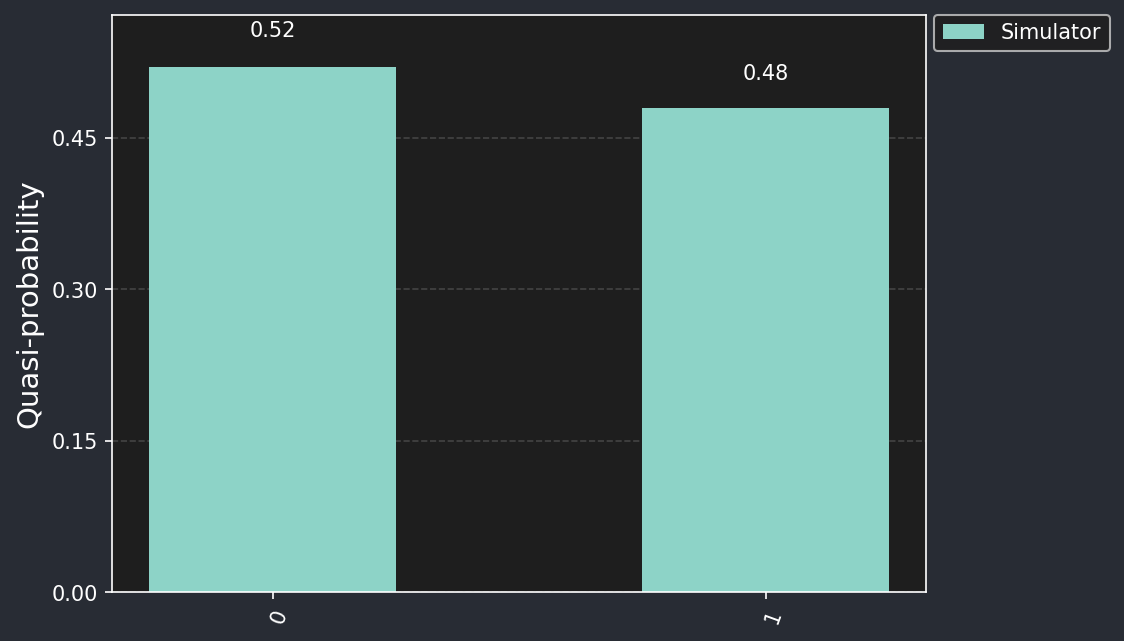

In [26]:
result_aer = job_aer.result()
counts_qc1_aer = result_aer[0].data.meas.get_counts()
plot_distribution([counts_qc1_aer], legend=['Simulator'])

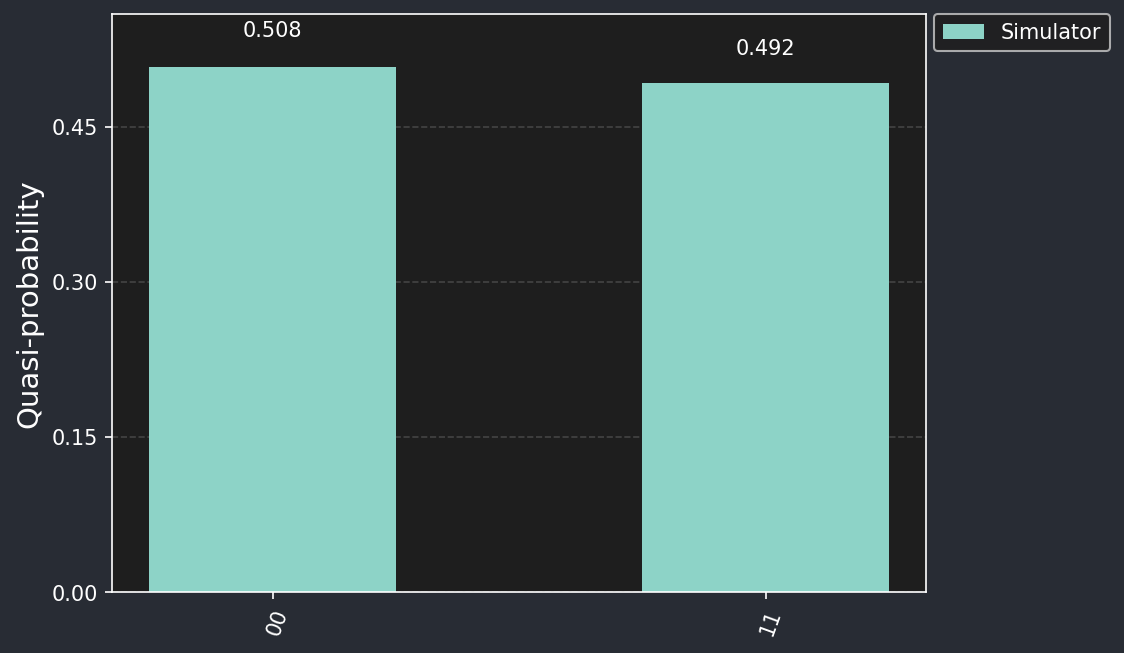

In [30]:
counts_qc2_aer = result_aer[1].data.measure.get_counts()
counts_qc2_aer_angle0 = result_aer[1].data.measure.get_counts(2)
plot_distribution([counts_qc2_aer_angle0], legend=['Simulator'])

___

## Estimator

`EstimatorV2(mode=None, options=None)`

In [ ]:
estimator_aer = runtime_EstimatorV2(backend=backend_aer)
